#**Introduction**

- K-Means is an unsupervised machine learning algorithm used to group similar data points into clusters based on distance.
- K-Means works best when data is **well-separated**, **structured**, and **circular in shape**.
- It is commonly used for customer segmentation, pattern recognition, and data grouping.

##**Import Libraries**

In [19]:
import pandas as pd   # data handling
import matplotlib.pyplot as plt   # plotting
import seaborn as sns   #better graphs

##**Create Dummy Dataset**

This creates synthetic clustered data.

Parameters:

- n_samples = 700 → total points
- centers = 2 → 2 clusters
- cluster_std = 1 → spread
- random_state → reproducible result

In [20]:
from sklearn.datasets import make_blobs

In [21]:
x, y = make_blobs(n_samples=700, centers=2, cluster_std=1, random_state=42)

In [22]:
x

array([[ 4.77341974,  1.82069985],
       [-1.68378127,  9.82779576],
       [ 6.03008639,  2.53097999],
       ...,
       [ 6.72825354,  1.83358006],
       [-2.43939554,  8.62897253],
       [-2.76878897,  7.51114318]])

##**Convert to DataFrame**

In [23]:
df = pd.DataFrame(x, columns = ["x1","x2"])

In [24]:
df

,x1,x2
0,4.773420,1.820700
1,-1.683781,9.827796
2,6.030086,2.530980
3,-2.778604,9.731828
4,-5.160167,10.105793
...,...,...
695,6.305353,2.987540
696,4.873665,0.417274
697,6.728254,1.833580
698,-2.439396,8.628973


##**Feature Scaling**

- KMeans uses distance
- Features must be same scale

In [25]:
from sklearn.preprocessing import StandardScaler

scler = StandardScaler()
X_scaled = scler.fit_transform(df)

In [26]:
X_scaled

array([[ 0.97689919, -1.020064  ],
       [-0.74095081,  1.18581838],
       [ 1.31121816, -0.82438826],
       ...,
       [ 1.49695598, -1.01651562],
       [-0.94197165,  0.85555344],
       [-1.02960227,  0.54760158]])

##**Find Best K (Elbow Method)**

This calculates inertia for each K

- Inertia = distance inside cluster
- Lower inertia = better clustering

In [27]:
inertia = []
k_range = range(1,11)

In [28]:
from sklearn.cluster import KMeans
for k in k_range:
    kmeans  = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

In [29]:
inertia

[1400.000000000001,
 100.06936893999085,
 83.63960676215606,
 73.24110558689576,
 54.28315957019537,
 44.62939103276432,
 39.834628434510485,
 35.60785757260922,
 31.423015432454044,
 29.877140329856964]

##**Plot Elbow Graph**

We choose K where elbow occurs

Notebook selects:

k = 3

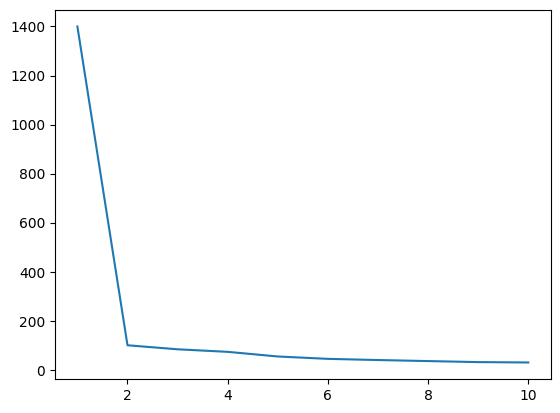

In [30]:
# Graph Plotting
plt.plot(k_range, inertia)
plt.show()

##**Apply Final KMeans**

- fits model
- assigns cluster labels

In [31]:
K_means_final = KMeans(n_clusters = 2, random_state=42)

In [32]:
cluster_labal = K_means_final.fit_predict(X_scaled)

##**Add Cluster to Data**

In [33]:
df["cluster"] = cluster_labal

In [34]:
df

,x1,x2,cluster
0,4.773420,1.820700,0
1,-1.683781,9.827796,1
2,6.030086,2.530980,0
3,-2.778604,9.731828,1
4,-5.160167,10.105793,1
...,...,...,...
695,6.305353,2.987540,0
696,4.873665,0.417274,0
697,6.728254,1.833580,0
698,-2.439396,8.628973,1


##**Visualize Clusters**

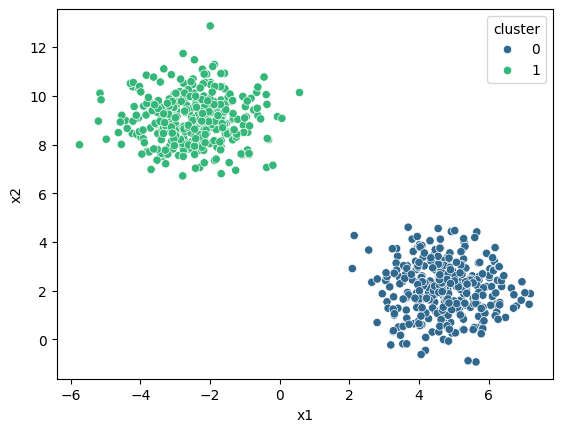

In [35]:
# Scatterplot - find the relationship between two numerical values
sns.scatterplot(x=df["x1"], y = df["x2"], hue=df["cluster"],palette = 'viridis')
plt.show()

##**Conclusion**
1. K-Means clustering grouped similar data points into two clear clusters based on distance.
2. The Elbow Method helped identify the optimal number of clusters (K = 3).
3. Feature scaling improved clustering performance by standardizing data values.
4. Cluster visualization showed well-separated and homogeneous groups.
5. K-Means worked effectively for circular and evenly distributed data points.